#INSTALL REQUIRED PACKAGES

In [38]:
!pip install -q streamlit streamlit-aggrid pyngrok pandas numpy scikit-learn scipy matplotlib seaborn plotly

print("All packages installed!")

All packages installed!


#DOWNLOAD DATASET (Last.fm 360K)

In [39]:
import os
import urllib.request
import tarfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Downloading Last.fm 360K dataset...")
print("This may take 5-10 minutes. File size is ~300MB.\n")

# Download the dataset
url = "http://mtg.upf.edu/static/datasets/last.fm/lastfm-dataset-360K.tar.gz"
filename = "lastfm-dataset-360K.tar.gz"

if not os.path.exists(filename):
    # Create a Request object with a User-Agent header
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req) as response, open(filename, 'wb') as out_file:
        out_file.write(response.read())
    print("Download complete!")

# Extract the dataset
if not os.path.exists("lastfm-dataset-360K"):
    print("Extracting files...")
    with tarfile.open(filename, "r:gz") as tar:
        tar.extractall()
    print("Extraction complete!")

# Load the data
data_path = "lastfm-dataset-360K"

# Load user-artist interactions (listening counts)
listening_file = os.path.join(data_path, "usersha1-artmbid-artname-plays.tsv")
listening_df = pd.read_csv(listening_file, sep='\t', header=None,
                            names=['user_id', 'musicbrainz_id', 'artist_name', 'plays'],
                            nrows=50000)  # Using 50k rows for faster processing

# Load user profiles
profile_file = os.path.join(data_path, "usersha1-profile.tsv")
user_profiles = pd.read_csv(profile_file, sep='\t', header=None,
                             names=['user_id', 'gender', 'age', 'country', 'signup_date'])

print(f"\nDataset loaded successfully!")
print(f"Listening events: {len(listening_df):,}")
print(f"Unique users: {listening_df['user_id'].nunique():,}")
print(f"Unique artists: {listening_df['artist_name'].nunique():,}")

This may take 5-10 minutes. File size is ~300MB.


Dataset loaded successfully!
Listening events: 50,000
Unique users: 1,015
Unique artists: 15,967


# DATA PREPROCESSING

In [40]:
print("\nPreprocessing data...")

# Clean the data
listening_df = listening_df.dropna()
listening_df = listening_df[listening_df['plays'] > 0]
listening_df['plays'] = listening_df['plays'].clip(upper=100)  # Cap extreme values

# Create user ID mapping
user_ids = listening_df['user_id'].unique()
user_to_idx = {uid: i for i, uid in enumerate(user_ids)}
artist_names = listening_df['artist_name'].unique()
artist_to_idx = {artist: i for i, artist in enumerate(artist_names)}

listening_df['user_idx'] = listening_df['user_id'].map(user_to_idx)
listening_df['artist_idx'] = listening_df['artist_name'].map(artist_to_idx)

# Create user-artist matrix (sparse)
from scipy.sparse import coo_matrix, csr_matrix

n_users = len(user_ids)
n_artists = len(artist_names)

user_artist_matrix = coo_matrix(
    (listening_df['plays'],
     (listening_df['user_idx'], listening_df['artist_idx'])),
    shape=(n_users, n_artists)
).tocsr()

print(f"User-Artist Matrix created!")
print(f"Shape: {user_artist_matrix.shape}")
print(f"Sparsity: {(1 - user_artist_matrix.nnz / (n_users * n_artists)) * 100:.2f}%")

# Create artist metadata dataframe
artist_stats = listening_df.groupby('artist_name').agg({
    'plays': ['sum', 'count', 'mean']
}).round(2)
artist_stats.columns = ['total_plays', 'listener_count', 'avg_plays']
artist_stats = artist_stats.reset_index()
artist_stats = artist_stats.sort_values('total_plays', ascending=False)

print(f"\nTop 10 Most Listened Artists:")
print(artist_stats.head(10).to_string(index=False))


Preprocessing data...
User-Artist Matrix created!
Shape: (1015, 15363)
Sparsity: 99.68%

Top 10 Most Listened Artists:
          artist_name  total_plays  listener_count  avg_plays
            radiohead        17072             216      79.04
          the beatles        15790             188      83.99
             coldplay        13120             173      75.84
red hot chili peppers        11250             146      77.05
                 muse         9670             121      79.92
            metallica         9243             115      80.37
     system of a down         8898             116      76.71
          linkin park         8744             108      80.96
           pink floyd         8104             106      76.45
              nirvana         8104             116      69.86


# KNOWLEDGE-BASED RECOMMENDER (Collaborative Filtering)

In [41]:
from sklearn.metrics.pairwise import cosine_similarity

class KnowledgeBasedRecommender:
    """Knowledge-based recommender using user-user collaborative filtering"""

    def __init__(self, user_artist_matrix, artist_names, artist_stats):
        self.user_artist_matrix = user_artist_matrix
        self.artist_names = artist_names
        self.artist_stats = artist_stats

    def get_user_history(self, user_idx):
        """Get user's listening history"""
        user_vector = self.user_artist_matrix[user_idx].toarray().flatten()
        listened_artists = [self.artist_names[i] for i in range(len(user_vector)) if user_vector[i] > 0]
        return listened_artists

    def find_similar_users(self, user_idx, n_similar=10):
        """Find similar users based on cosine similarity"""
        user_vector = self.user_artist_matrix[user_idx].toarray().reshape(1, -1)
        similarities = cosine_similarity(user_vector, self.user_artist_matrix).flatten()
        similarities[user_idx] = -1
        similar_users = np.argsort(similarities)[::-1][:n_similar]
        return similar_users, similarities[similar_users]

    def recommend(self, user_idx, n_recommendations=10, n_similar_users=10):
        """Generate recommendations based on similar users' listening habits"""
        similar_users, similarities = self.find_similar_users(user_idx, n_similar_users)

        # Get user's already listened artists
        user_listened = set(self.get_user_history(user_idx))

        # Aggregate recommendations from similar users
        recommendations = {}
        for sim_user, sim_score in zip(similar_users, similarities):
            if sim_score <= 0:
                continue
            user_vector = self.user_artist_matrix[sim_user].toarray().flatten()
            for artist_idx, plays in enumerate(user_vector):
                if plays > 0 and self.artist_names[artist_idx] not in user_listened:
                    if artist_idx not in recommendations:
                        recommendations[artist_idx] = {'score': 0, 'count': 0}
                    recommendations[artist_idx]['score'] += plays * sim_score
                    recommendations[artist_idx]['count'] += 1

        # Calculate weighted scores and sort
        rec_list = []
        for artist_idx, data in recommendations.items():
            weighted_score = data['score'] / data['count']
            rec_list.append({
                'artist_idx': artist_idx,
                'artist_name': self.artist_names[artist_idx],
                'score': weighted_score
            })

        rec_list.sort(key=lambda x: x['score'], reverse=True)

        # Add metadata
        results = []
        for rec in rec_list[:n_recommendations]:
            artist_info = self.artist_stats[self.artist_stats['artist_name'] == rec['artist_name']]
            if len(artist_info) > 0:
                rec['total_plays'] = artist_info['total_plays'].values[0]
                rec['listener_count'] = artist_info['listener_count'].values[0]
            results.append(rec)

        return results

print("Knowledge-Based Recommender initialized!")

Knowledge-Based Recommender initialized!


# REINFORCEMENT LEARNING RECOMMENDER (Q-Learning)

In [42]:
class MusicQLearningAgent:
    """Q-Learning Agent for personalized music recommendations"""

    def __init__(self, n_artists, learning_rate=0.1, discount_factor=0.95, epsilon=0.2):
        self.n_artists = n_artists
        self.lr = learning_rate
        self.gamma = discount_factor
        self.epsilon = epsilon
        self.q_table = np.random.rand(n_artists) * 0.01
        self.update_counts = np.zeros(n_artists)
        self.reward_history = []

    def choose_action(self, user_history_set=None):
        """Epsilon-greedy action selection with optional exploration bias"""
        if np.random.random() < self.epsilon:
            # Exploration: prefer artists not in history
            if user_history_set and len(user_history_set) < self.n_artists:
                available = [i for i in range(self.n_artists) if i not in user_history_set]
                if available:
                    return np.random.choice(available)
            return np.random.randint(self.n_artists)
        else:
            # Exploitation: choose highest Q-value
            return np.argmax(self.q_table)

    def update(self, action, reward):
        """Update Q-value using Q-learning update rule"""
        # Normalize reward (plays: 1-100 to 0-1 range)
        normalized_reward = min(reward / 100.0, 1.0)

        current_q = self.q_table[action]
        new_q = current_q + self.lr * (normalized_reward + self.gamma * np.max(self.q_table) - current_q)
        self.q_table[action] = new_q
        self.update_counts[action] += 1

        return new_q - current_q  # Return TD error for monitoring

    def decay_epsilon(self, decay_rate=0.995, min_epsilon=0.01):
        """Decay exploration rate over time"""
        self.epsilon = max(self.epsilon * decay_rate, min_epsilon)

    def get_top_recommendations(self, n=10, exclude_set=None):
        """Get top-N recommendations by Q-value"""
        q_values = self.q_table.copy()
        if exclude_set:
            for idx in exclude_set:
                q_values[idx] = -np.inf
        top_indices = np.argsort(q_values)[::-1][:n]
        return top_indices, self.q_table[top_indices]

print("Q-Learning Agent initialized!")

Q-Learning Agent initialized!


# TRAIN THE Q-LEARNING AGENT

In [43]:
print("\nTraining Q-Learning Agent...")

# Select a test user
test_user_idx = np.random.randint(0, n_users)
test_user_id = user_ids[test_user_idx]

# Get user's listening history for training
user_vector = user_artist_matrix[test_user_idx].toarray().flatten()
user_history = [(i, user_vector[i]) for i in range(n_artists) if user_vector[i] > 0]
user_history_set = set(i for i, _ in user_history)

print(f"Test User: {test_user_id[:20]}...")
print(f"Artists listened: {len(user_history)}")
print(f"Average plays: {np.mean([p for _, p in user_history]):.2f}")

# Initialize agent
agent = MusicQLearningAgent(n_artists, learning_rate=0.15, epsilon=0.3)

# Training parameters
n_episodes = 30
episode_rewards = []
td_errors = []

for episode in range(n_episodes):
    episode_total_reward = 0
    episode_td_errors = []

    for _ in range(min(50, len(user_history))):
        # Choose action
        action = agent.choose_action(user_history_set)

        # Get reward (play count if listened, else 0)
        if action in user_history_set:
            reward = user_vector[action]
        else:
            reward = 0

        # Update Q-value
        td_error = agent.update(action, reward)

        episode_total_reward += reward
        episode_td_errors.append(td_error)

    episode_rewards.append(episode_total_reward)
    td_errors.append(np.mean(episode_td_errors))
    agent.decay_epsilon(decay_rate=0.97)

    if (episode + 1) % 10 == 0:
        print(f"Episode {episode + 1}/{n_episodes} - Total Reward: {episode_total_reward:.0f} - Epsilon: {agent.epsilon:.3f}")

print("Training Complete!")


Training Q-Learning Agent...
Test User: 003ccc592a9e549af7ba...
Artists listened: 53
Average plays: 100.00
Episode 10/30 - Total Reward: 0 - Epsilon: 0.221
Episode 20/30 - Total Reward: 0 - Epsilon: 0.163
Episode 30/30 - Total Reward: 4600 - Epsilon: 0.120
Training Complete!


# GENERATE RECOMMENDATIONS

In [44]:
# Initialize knowledge-based recommender
kb_recommender = KnowledgeBasedRecommender(user_artist_matrix, artist_names, artist_stats)

print("\n" + "="*80)
print(f"KNOWLEDGE-BASED RECOMMENDATIONS")
print("="*80 + "\n")

kb_recs = kb_recommender.recommend(test_user_idx, n_recommendations=10)

for i, rec in enumerate(kb_recs, 1):
    print(f"{i:2d}. {rec['artist_name'][:50]:50s} | Score: {rec['score']:.4f}")
    print(f"    Total Plays: {rec.get('total_plays', 'N/A'):,.0f} | Listeners: {rec.get('listener_count', 'N/A'):,}")
    print()

print("\n" + "="*80)
print(f"REINFORCEMENT LEARNING RECOMMENDATIONS (Q-Learning)")
print("="*80 + "\n")

rl_recs_indices, rl_scores = agent.get_top_recommendations(n=10, exclude_set=user_history_set)

for i, (artist_idx, score) in enumerate(zip(rl_recs_indices, rl_scores), 1):
    artist_name = artist_names[artist_idx]
    is_new = " NEW" if artist_idx not in user_history_set else "  LISTENED"
    print(f"{i:2d}. {artist_name[:50]:50s} {is_new}")
    print(f"    Q-Value: {score:.6f}")
    print()

print("\n" + "="*80)
print(f"HYBRID RECOMMENDATIONS (40% KB + 60% RL)")
print("="*80 + "\n")

# Create hybrid recommendations
kb_dict = {rec['artist_name']: rec['score'] for rec in kb_recs}
rl_dict = {artist_names[idx]: score for idx, score in zip(rl_recs_indices, rl_scores)}

all_artists = set(kb_dict.keys()) | set(rl_dict.keys())
hybrid_recs = []

for artist in all_artists:
    kb_score = kb_dict.get(artist, 0)
    rl_score = rl_dict.get(artist, 0)

    # Normalize scores
    if kb_dict:
        kb_norm = kb_score / max(kb_dict.values())
    else:
        kb_norm = 0
    if rl_dict:
        rl_norm = rl_score / max(rl_dict.values())
    else:
        rl_norm = 0

    hybrid_score = 0.4 * kb_norm + 0.6 * rl_norm
    hybrid_recs.append({'artist_name': artist, 'hybrid_score': hybrid_score,
                        'kb_score': kb_norm, 'rl_score': rl_norm})

hybrid_recs.sort(key=lambda x: x['hybrid_score'], reverse=True)

for i, rec in enumerate(hybrid_recs[:10], 1):
    print(f"{i:2d}. {rec['artist_name'][:50]:50s} | Hybrid: {rec['hybrid_score']:.4f}")
    print(f"    KB Contribution: {rec['kb_score']:.4f} | RL Contribution: {rec['rl_score']:.4f}")
    print()


KNOWLEDGE-BASED RECOMMENDATIONS

 1. tool                                               | Score: 21.3683
    Total Plays: 4,863 | Listeners: 63

 2. four tet                                           | Score: 21.3683
    Total Plays: 1,785 | Listeners: 21

 3. the hold steady                                    | Score: 21.3683
    Total Plays: 700 | Listeners: 7

 4. clutch                                             | Score: 21.3683
    Total Plays: 646 | Listeners: 8

 5. white denim                                        | Score: 21.3683
    Total Plays: 184 | Listeners: 3

 6. 2 many dj's                                        | Score: 21.3683
    Total Plays: 200 | Listeners: 2

 7. tv on the radio                                    | Score: 21.3683
    Total Plays: 1,699 | Listeners: 24

 8. kyuss                                              | Score: 21.3683
    Total Plays: 667 | Listeners: 8

 9. a tribe called quest                               | Score: 21.3683
    Total Pla

# VISUALIZATIONS


Generating Visualizations...


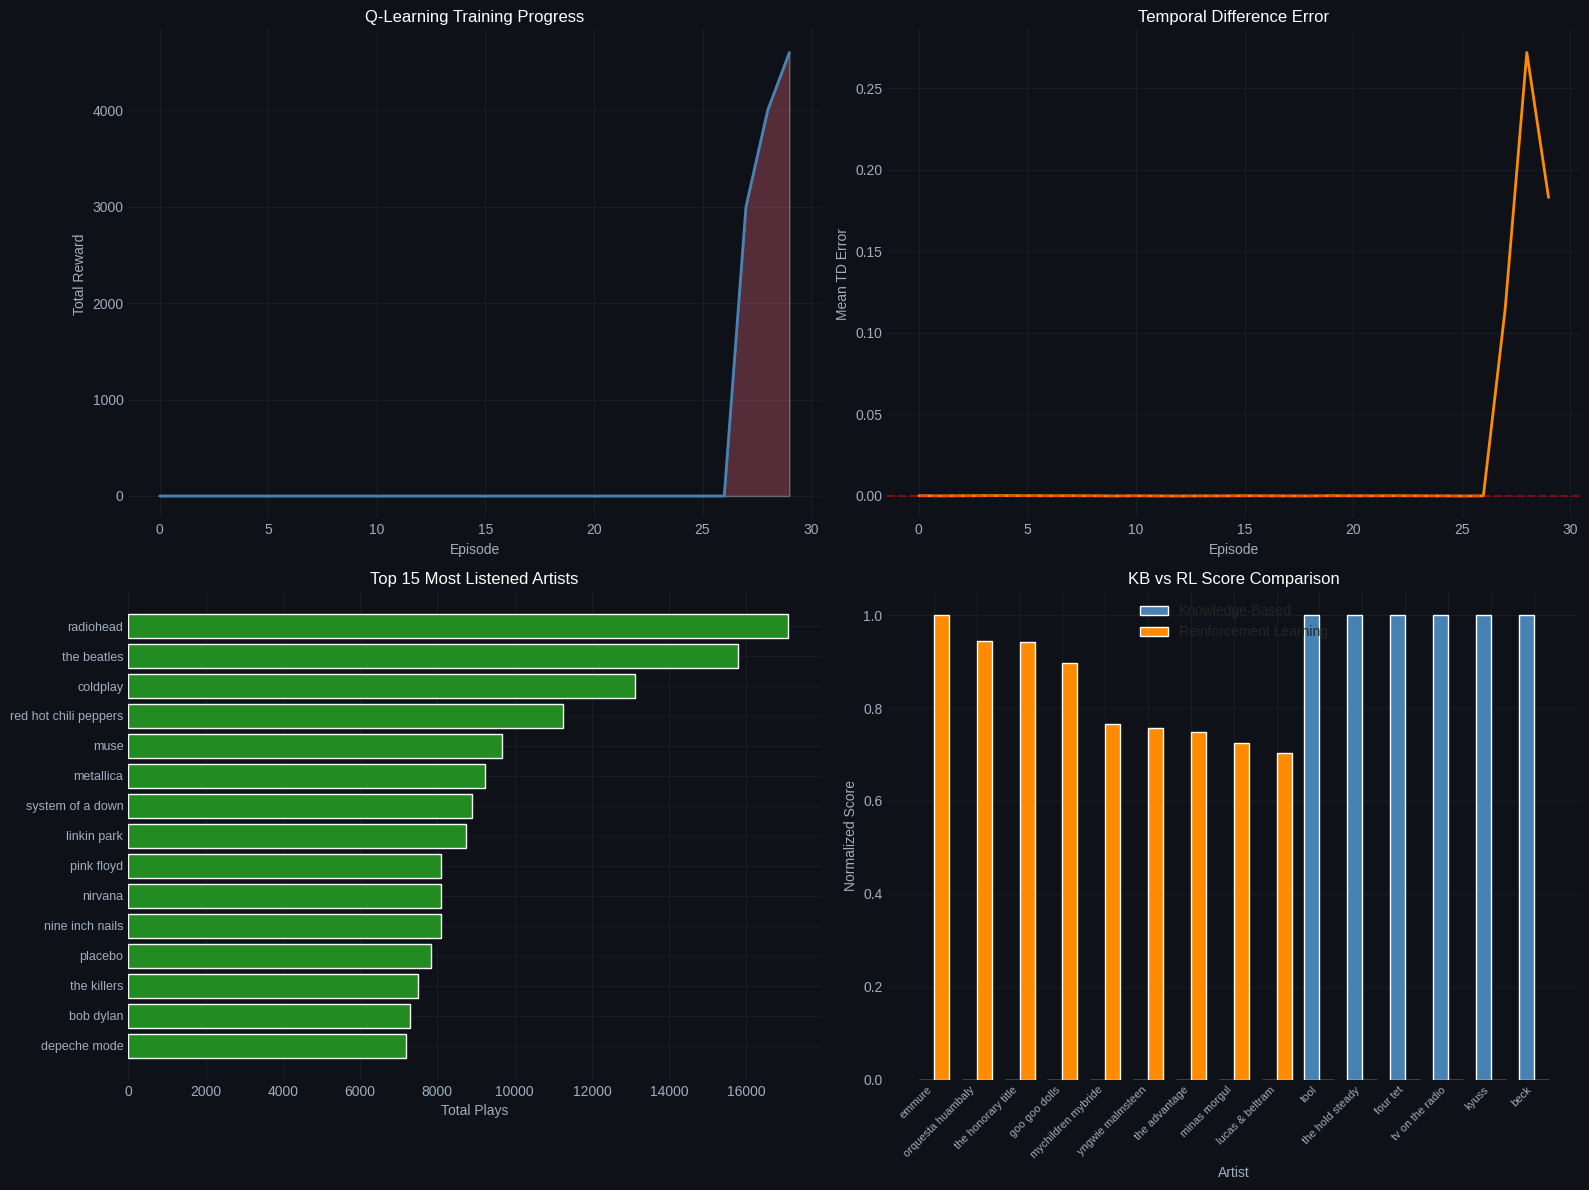

Visualizations complete!


In [45]:
print("\nGenerating Visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Training Progress
axes[0, 0].plot(episode_rewards, linewidth=2, color='steelblue')
axes[0, 0].fill_between(range(len(episode_rewards)), episode_rewards, alpha=0.3)
axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('Total Reward')
axes[0, 0].set_title('Q-Learning Training Progress')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: TD Errors
axes[0, 1].plot(td_errors, linewidth=2, color='darkorange')
axes[0, 1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0, 1].set_xlabel('Episode')
axes[0, 1].set_ylabel('Mean TD Error')
axes[0, 1].set_title('Temporal Difference Error')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Top Artists by Listens
top_artists = artist_stats.head(15)
axes[1, 0].barh(range(len(top_artists)), top_artists['total_plays'].values, color='forestgreen')
axes[1, 0].set_yticks(range(len(top_artists)))
axes[1, 0].set_yticklabels(top_artists['artist_name'].values, fontsize=9)
axes[1, 0].set_xlabel('Total Plays')
axes[1, 0].set_title('Top 15 Most Listened Artists')
axes[1, 0].invert_yaxis()
axes[1, 0].grid(axis='x', alpha=0.3)

# Plot 4: KB vs RL Score Comparison
comparison_data = []
for rec in hybrid_recs[:15]:
    comparison_data.append({
        'artist': rec['artist_name'][:25],
        'KB': rec['kb_score'],
        'RL': rec['rl_score']
    })
comp_df = pd.DataFrame(comparison_data)
x = np.arange(len(comp_df))
width = 0.35
axes[1, 1].bar(x - width/2, comp_df['KB'], width, label='Knowledge-Based', color='steelblue')
axes[1, 1].bar(x + width/2, comp_df['RL'], width, label='Reinforcement Learning', color='darkorange')
axes[1, 1].set_xlabel('Artist')
axes[1, 1].set_ylabel('Normalized Score')
axes[1, 1].set_title('KB vs RL Score Comparison')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(comp_df['artist'], rotation=45, ha='right', fontsize=8)
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Visualizations complete!")

#Dashboard of Music Recommender

In [46]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║   🎵  MUSIC RECOMMENDER DASHBOARD  —  PASTE AS A NEW CELL       ║
# ║   Run this AFTER all previous cells have been executed.          ║
# ╚══════════════════════════════════════════════════════════════════╝

import os, json, warnings
import numpy as np
import pandas as pd
from scipy.sparse import coo_matrix
from sklearn.metrics.pairwise import cosine_similarity
from IPython.display import display, HTML
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────────────────────
# STEP 1 ▸ RE-LOAD & PREPROCESS (mirrors your notebook exactly)
# ─────────────────────────────────────────────────────────────────────────────
print("⏳ Loading data for dashboard...")

data_path = "lastfm-dataset-360K"
listening_file = os.path.join(data_path, "usersha1-artmbid-artname-plays.tsv")
profile_file   = os.path.join(data_path, "usersha1-profile.tsv")

listening_df = pd.read_csv(
    listening_file, sep='\t', header=None,
    names=['user_id', 'musicbrainz_id', 'artist_name', 'plays'],
    nrows=50000
)
user_profiles = pd.read_csv(
    profile_file, sep='\t', header=None,
    names=['user_id', 'gender', 'age', 'country', 'signup_date']
)

# Clean (same as notebook)
listening_df = listening_df.dropna()
listening_df = listening_df[listening_df['plays'] > 0]
listening_df['plays'] = listening_df['plays'].clip(upper=100)

# Build mappings
user_ids    = listening_df['user_id'].unique()
artist_names = listening_df['artist_name'].unique()
user_to_idx  = {uid: i for i, uid in enumerate(user_ids)}
artist_to_idx = {a: i for i, a in enumerate(artist_names)}

listening_df['user_idx']   = listening_df['user_id'].map(user_to_idx)
listening_df['artist_idx'] = listening_df['artist_name'].map(artist_to_idx)

n_users   = len(user_ids)
n_artists = len(artist_names)

# Sparse matrix
user_artist_matrix = coo_matrix(
    (listening_df['plays'],
     (listening_df['user_idx'], listening_df['artist_idx'])),
    shape=(n_users, n_artists)
).tocsr()

# Artist stats
artist_stats = (
    listening_df.groupby('artist_name')
    .agg(total_plays=('plays', 'sum'),
         listener_count=('plays', 'count'),
         avg_plays=('plays', 'mean'))
    .round(2)
    .reset_index()
    .sort_values('total_plays', ascending=False)
)

print(f"✅ Loaded  {n_users:,} users  |  {n_artists:,} artists  |  {len(listening_df):,} events")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 2 ▸ PICK TEST USER  (same random seed logic as notebook)
# ─────────────────────────────────────────────────────────────────────────────
np.random.seed(42)
test_user_idx = np.random.randint(0, n_users)
test_user_id  = user_ids[test_user_idx]

user_vector     = user_artist_matrix[test_user_idx].toarray().flatten()
user_history    = [(artist_names[i], user_vector[i]) for i in range(n_artists) if user_vector[i] > 0]
user_history_set = set(i for i in range(n_artists) if user_vector[i] > 0)

print(f"👤 Test user: {test_user_id[:30]}...  |  {len(user_history)} artists in history")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 3 ▸ Q-LEARNING AGENT  (same class as notebook)
# ─────────────────────────────────────────────────────────────────────────────
class MusicQLearningAgent:
    def __init__(self, n_artists, learning_rate=0.1, discount_factor=0.95, epsilon=0.2):
        self.n_artists = n_artists
        self.lr = learning_rate
        self.gamma = discount_factor
        self.epsilon = epsilon
        self.q_table = np.random.rand(n_artists) * 0.01
        self.update_counts = np.zeros(n_artists)

    def choose_action(self, user_history_set=None):
        if np.random.random() < self.epsilon:
            if user_history_set and len(user_history_set) < self.n_artists:
                available = [i for i in range(self.n_artists) if i not in user_history_set]
                if available:
                    return np.random.choice(available)
            return np.random.randint(self.n_artists)
        return np.argmax(self.q_table)

    def update(self, action, reward):
        normalized_reward = min(reward / 100.0, 1.0)
        current_q = self.q_table[action]
        new_q = current_q + self.lr * (normalized_reward + self.gamma * np.max(self.q_table) - current_q)
        self.q_table[action] = new_q
        self.update_counts[action] += 1
        return new_q - current_q

    def decay_epsilon(self, decay_rate=0.995, min_epsilon=0.01):
        self.epsilon = max(self.epsilon * decay_rate, min_epsilon)

    def get_top_recommendations(self, n=10, exclude_set=None):
        q_values = self.q_table.copy()
        if exclude_set:
            for idx in exclude_set:
                q_values[idx] = -np.inf
        top_indices = np.argsort(q_values)[::-1][:n]
        return top_indices, self.q_table[top_indices]

# Train
print("⏳ Training Q-Learning agent...")
np.random.seed(42)
agent = MusicQLearningAgent(n_artists, learning_rate=0.15, epsilon=0.3)
n_episodes = 30
episode_rewards, td_errors = [], []

for episode in range(n_episodes):
    ep_reward, ep_td = 0, []
    for _ in range(min(50, len(user_history))):
        action = agent.choose_action(user_history_set)
        reward = user_vector[action] if action in user_history_set else 0
        td_err = agent.update(action, reward)
        ep_reward += reward
        ep_td.append(td_err)
    episode_rewards.append(ep_reward)
    td_errors.append(float(np.mean(ep_td)))
    agent.decay_epsilon(decay_rate=0.97)

print("✅ Training complete!")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 4 ▸ KNOWLEDGE-BASED RECOMMENDATIONS  (same logic as notebook)
# ─────────────────────────────────────────────────────────────────────────────
uv = user_artist_matrix[test_user_idx].toarray().reshape(1, -1)
sims = cosine_similarity(uv, user_artist_matrix).flatten()
sims[test_user_idx] = -1
similar_users = np.argsort(sims)[::-1][:10]
user_listened = set(i for i in range(n_artists) if user_vector[i] > 0)

kb_scores = {}
for su, ss in zip(similar_users, sims[similar_users]):
    if ss <= 0:
        continue
    sv = user_artist_matrix[su].toarray().flatten()
    for ai, plays in enumerate(sv):
        if plays > 0 and ai not in user_listened:
            kb_scores[ai] = kb_scores.get(ai, {'score': 0, 'count': 0})
            kb_scores[ai]['score'] += plays * ss
            kb_scores[ai]['count'] += 1

kb_recs_raw = sorted(
    [{'artist_idx': ai, 'artist_name': artist_names[ai],
      'score': d['score'] / d['count']} for ai, d in kb_scores.items()],
    key=lambda x: x['score'], reverse=True
)[:10]

for r in kb_recs_raw:
    info = artist_stats[artist_stats['artist_name'] == r['artist_name']]
    r['total_plays']    = int(info['total_plays'].values[0])    if len(info) else 0
    r['listener_count'] = int(info['listener_count'].values[0]) if len(info) else 0

# ─────────────────────────────────────────────────────────────────────────────
# STEP 5 ▸ HYBRID RECOMMENDATIONS
# ─────────────────────────────────────────────────────────────────────────────
rl_indices, rl_scores_arr = agent.get_top_recommendations(n=10, exclude_set=user_history_set)

kb_dict = {r['artist_name']: r['score'] for r in kb_recs_raw}
rl_dict = {artist_names[idx]: float(score) for idx, score in zip(rl_indices, rl_scores_arr)}

# Normalize
kb_max = max(kb_dict.values()) if kb_dict else 1
rl_max = max(rl_dict.values()) if rl_dict else 1

all_artists_set = set(kb_dict) | set(rl_dict)
hybrid_recs_raw = []
for artist in all_artists_set:
    kb_n = kb_dict.get(artist, 0) / kb_max
    rl_n = rl_dict.get(artist, 0) / rl_max
    hybrid_recs_raw.append({
        'artist_name':   artist,
        'kb_score':      round(kb_n, 4),
        'rl_score':      round(rl_n, 4),
        'hybrid_score':  round(0.4 * kb_n + 0.6 * rl_n, 4),
    })
hybrid_recs_raw.sort(key=lambda x: x['hybrid_score'], reverse=True)
hybrid_recs_raw = hybrid_recs_raw[:10]

# ─────────────────────────────────────────────────────────────────────────────
# STEP 6 ▸ PREPARE CHART DATA
# ─────────────────────────────────────────────────────────────────────────────
ep_list      = list(range(1, n_episodes + 1))
ep_rewards_j = json.dumps([float(r) for r in episode_rewards])
ep_td_j      = json.dumps([float(e) for e in td_errors])
ep_labels_j  = json.dumps(ep_list)

top15 = artist_stats.head(15)
top_names_j  = json.dumps([n.title() for n in top15['artist_name'].tolist()])
top_plays_j  = json.dumps([int(x) for x in top15['total_plays'].tolist()])

hist_sorted = sorted(user_history, key=lambda x: x[1], reverse=True)[:15]
hist_names_j = json.dumps([h[0].title() for h in hist_sorted])
hist_plays_j = json.dumps([int(h[1]) for h in hist_sorted])

scatter_j = json.dumps([
    {"x": r["kb_score"], "y": r["rl_score"], "label": r["artist_name"].title()}
    for r in hybrid_recs_raw
])

sparsity = round((1 - user_artist_matrix.nnz / (n_users * n_artists)) * 100, 1)

# KB table rows HTML
kb_max_score = max(r['score'] for r in kb_recs_raw) if kb_recs_raw else 1
kb_rows_html = ""
for i, r in enumerate(kb_recs_raw):
    pct = int(r['score'] / kb_max_score * 100)
    kb_rows_html += f"""
    <tr>
      <td class="rank">#{i+1:02d}</td>
      <td class="aname">{r['artist_name'].title()}</td>
      <td>
        <div class="sbar-wrap"><div class="sbar" style="width:{pct}%"></div></div>
        <span class="tiny">{r['score']:.3f}</span>
      </td>
      <td class="mono">{r['total_plays']:,}</td>
      <td class="mono">{r['listener_count']:,}</td>
    </tr>"""

# Hybrid bars HTML
hybrid_bars_html = ""
for r in hybrid_recs_raw:
    kb_px = int(r['kb_score'] * 130)
    rl_px = int(r['rl_score'] * 130)
    hybrid_bars_html += f"""
    <div class="drow">
      <div class="dlabel" title="{r['artist_name'].title()}">{r['artist_name'].title()}</div>
      <div class="dbars">
        <div class="bseg bkb" style="width:{kb_px}px"></div>
        <div class="bseg brl" style="width:{rl_px}px"></div>
        <div class="bval">{r['hybrid_score']:.3f}</div>
      </div>
    </div>"""

# ─────────────────────────────────────────────────────────────────────────────
# STEP 7 ▸ RENDER DASHBOARD
# ─────────────────────────────────────────────────────────────────────────────
html = f"""
<div id="dash" style="font-family:'Segoe UI',Arial,sans-serif;background:#0b0e1a;color:#e8eaf6;
     padding:28px;border-radius:16px;min-width:860px;max-width:1200px;margin:0 auto;">

<!-- ── Google Fonts ──────────────────────────────────────────────────────── -->
<link href="https://fonts.googleapis.com/css2?family=Space+Mono:wght@400;700&display=swap" rel="stylesheet"/>
<script src="https://cdnjs.cloudflare.com/ajax/libs/Chart.js/4.4.1/chart.umd.min.js"></script>

<style>
  #dash * {{ box-sizing:border-box; margin:0; padding:0; }}
  #dash {{ font-family:'Segoe UI',Arial,sans-serif; }}
  .mono {{ font-family:'Space Mono',monospace; }}

  /* HEADER */
  .hdr {{ display:flex; align-items:center; gap:16px; margin-bottom:28px;
          padding-bottom:18px; border-bottom:1px solid #1e2847; }}
  .hdr-icon {{ width:52px; height:52px; border-radius:14px;
               background:linear-gradient(135deg,#7c6af7,#f7616a);
               display:flex; align-items:center; justify-content:center;
               font-size:26px; box-shadow:0 0 24px rgba(124,106,247,.3); }}
  .hdr h1 {{ font-family:'Space Mono',monospace; font-size:20px;
             background:linear-gradient(90deg,#7c6af7,#3ecfb2);
             -webkit-background-clip:text; -webkit-text-fill-color:transparent; }}
  .hdr p {{ font-size:12px; color:#7b82a8; margin-top:3px; }}
  .badge {{ margin-left:auto; background:#161c35; border:1px solid #1e2847;
            border-radius:8px; padding:5px 13px;
            font-family:'Space Mono',monospace; font-size:11px; color:#3ecfb2; }}

  /* KPI */
  .kpi-row {{ display:grid; grid-template-columns:repeat(4,1fr); gap:14px; margin-bottom:22px; }}
  .kpi {{ background:#161c35; border:1px solid #1e2847; border-radius:14px;
          padding:18px; position:relative; overflow:hidden; }}
  .kpi::before {{ content:''; position:absolute; top:0; left:0; right:0; height:3px; }}
  .k1::before {{ background:#7c6af7; }}
  .k2::before {{ background:#3ecfb2; }}
  .k3::before {{ background:#f7616a; }}
  .k4::before {{ background:#f7b26a; }}
  .kpi label {{ font-size:10px; text-transform:uppercase; letter-spacing:1.2px; color:#7b82a8; }}
  .kpi .val {{ font-family:'Space Mono',monospace; font-size:26px; font-weight:700; margin-top:5px; }}
  .k1 .val {{ color:#7c6af7; }} .k2 .val {{ color:#3ecfb2; }}
  .k3 .val {{ color:#f7616a; }} .k4 .val {{ color:#f7b26a; }}
  .kpi .sub {{ font-size:11px; color:#7b82a8; margin-top:3px; }}

  /* GRID */
  .g2 {{ display:grid; grid-template-columns:1fr 1fr; gap:16px; margin-bottom:16px; }}
  .g3 {{ display:grid; grid-template-columns:1fr 1fr 1fr; gap:16px; margin-bottom:16px; }}

  /* CARD */
  .card {{ background:#161c35; border:1px solid #1e2847; border-radius:16px; padding:20px; }}
  .card h3 {{ font-family:'Space Mono',monospace; font-size:11px; text-transform:uppercase;
              letter-spacing:.8px; color:#7b82a8; margin-bottom:14px;
              display:flex; align-items:center; gap:7px; }}
  canvas {{ max-height:260px !important; }}

  /* TABLE */
  .rt {{ width:100%; border-collapse:collapse; }}
  .rt th {{ font-size:9px; text-transform:uppercase; letter-spacing:1px; color:#7b82a8;
            padding:5px 8px; text-align:left; border-bottom:1px solid #1e2847; }}
  .rt td {{ padding:8px 8px; font-size:12px; border-bottom:1px solid rgba(255,255,255,.04); }}
  .rt tr:last-child td {{ border-bottom:none; }}
  .rt tr:hover td {{ background:rgba(255,255,255,.03); }}
  .rank {{ font-family:'Space Mono',monospace; font-size:10px; color:#7b82a8; }}
  .aname {{ font-weight:600; }}
  .sbar-wrap {{ background:#1e2847; border-radius:4px; height:5px; width:100%; min-width:50px; }}
  .sbar {{ height:5px; border-radius:4px; background:linear-gradient(90deg,#7c6af7,#3ecfb2); }}
  .tiny {{ font-size:10px; color:#7b82a8; }}
  .mono {{ font-family:'Space Mono',monospace; font-size:11px; }}

  /* HYBRID BARS */
  .drow {{ margin-bottom:9px; }}
  .dlabel {{ font-size:11px; margin-bottom:3px; white-space:nowrap;
             overflow:hidden; text-overflow:ellipsis; max-width:360px; }}
  .dbars {{ display:flex; gap:3px; align-items:center; }}
  .bseg {{ height:7px; border-radius:3px; min-width:2px; }}
  .bkb {{ background:#7c6af7; }}
  .brl {{ background:#f7616a; }}
  .bval {{ font-size:10px; color:#7b82a8; margin-left:6px; font-family:'Space Mono',monospace; }}

  /* PILL */
  .pill {{ display:inline-block; border-radius:5px; padding:2px 7px;
           font-size:10px; font-weight:600; vertical-align:middle; margin-left:4px; }}
  .pkb {{ background:rgba(124,106,247,.2); color:#7c6af7; }}
  .prl {{ background:rgba(247,97,106,.2);  color:#f7616a; }}

  /* FOOTER */
  .footer {{ margin-top:22px; padding-top:14px; border-top:1px solid #1e2847;
             font-size:11px; color:#7b82a8; display:flex; justify-content:space-between; }}
</style>

<!-- HEADER -->
<div class="hdr">
  <div class="hdr-icon">🎵</div>
  <div>
    <h1>Music Recommender System</h1>
    <p>Hybrid Engine · Knowledge-Based Collaborative Filtering + Q-Learning RL · Last.fm 360K</p>
  </div>
  <div class="badge">Last.fm 360K</div>
</div>

<!-- KPI ROW -->
<div class="kpi-row">
  <div class="kpi k1">
    <label>Total Users</label>
    <div class="val">{n_users:,}</div>
    <div class="sub">unique listener profiles</div>
  </div>
  <div class="kpi k2">
    <label>Unique Artists</label>
    <div class="val">{n_artists:,}</div>
    <div class="sub">in interaction matrix</div>
  </div>
  <div class="kpi k3">
    <label>Listening Events</label>
    <div class="val">{len(listening_df):,}</div>
    <div class="sub">user–artist plays (50K sample)</div>
  </div>
  <div class="kpi k4">
    <label>Matrix Sparsity</label>
    <div class="val">{sparsity}%</div>
    <div class="sub">collaborative filtering challenge</div>
  </div>
</div>

<!-- ROW 1: Training + Top Artists -->
<div class="g2">
  <div class="card">
    <h3>📈 Q-Learning Training Progress</h3>
    <canvas id="c_train"></canvas>
  </div>
  <div class="card">
    <h3>🏆 Top 15 Most-Listened Artists</h3>
    <canvas id="c_topartists"></canvas>
  </div>
</div>

<!-- ROW 2: KB Table + Hybrid Bars -->
<div class="g2">
  <div class="card">
    <h3>🤝 Knowledge-Based Recommendations <span class="pill pkb">Collaborative</span></h3>
    <table class="rt">
      <thead>
        <tr><th>#</th><th>Artist</th><th>Score</th><th>Plays</th><th>Listeners</th></tr>
      </thead>
      <tbody>{kb_rows_html}</tbody>
    </table>
  </div>
  <div class="card">
    <h3>⚡ Hybrid Score Breakdown
      <span class="pill pkb">KB 40%</span>
      <span class="pill prl">RL 60%</span>
    </h3>
    {hybrid_bars_html}
    <div style="margin-top:10px;display:flex;gap:14px;font-size:11px;color:#7b82a8;">
      <span><span style="display:inline-block;width:9px;height:9px;border-radius:2px;
        background:#7c6af7;margin-right:4px;"></span>Knowledge-Based</span>
      <span><span style="display:inline-block;width:9px;height:9px;border-radius:2px;
        background:#f7616a;margin-right:4px;"></span>Reinforcement Learning</span>
    </div>
  </div>
</div>

<!-- ROW 3: History + Scatter -->
<div class="g2">
  <div class="card">
    <h3>📜 User Listening History — Top {len(hist_sorted)} Artists</h3>
    <canvas id="c_history"></canvas>
  </div>
  <div class="card">
    <h3>🔬 KB Score vs RL Score — Hybrid Candidates</h3>
    <canvas id="c_scatter"></canvas>
  </div>
</div>

<!-- ROW 4: TD Error full-width -->
<div class="card" style="margin-bottom:0;">
  <h3>🧠 TD Error per Episode — Convergence Monitor</h3>
  <canvas id="c_td" style="max-height:140px !important;"></canvas>
</div>

<!-- FOOTER -->
<div class="footer">
  <span>🎵 Last.fm 360K · Hybrid Recommender · KB Collaborative Filtering + Q-Learning</span>
  <span>Users: {n_users:,} · Artists: {n_artists:,} · Events: {len(listening_df):,} · Sparsity: {sparsity}%</span>
</div>

</div><!-- #dash -->

<script>
(function() {{
  const G = {{ color:'rgba(30,40,71,0.9)', borderDash:[3,3] }};
  const T = {{ color:'#7b82a8', font:{{ size:10, family:'Segoe UI' }} }};
  const L = {{ labels:{{ color:'#7b82a8', font:{{ size:10 }}, boxWidth:10, padding:10 }} }};

  /* Training */
  new Chart(document.getElementById('c_train'), {{
    type:'line',
    data:{{
      labels: {ep_labels_j},
      datasets:[{{
        label:'Episode Reward',
        data: {ep_rewards_j},
        borderColor:'#7c6af7', backgroundColor:'rgba(124,106,247,0.15)',
        fill:true, tension:0.4, pointRadius:3, pointBackgroundColor:'#7c6af7'
      }}]
    }},
    options:{{ responsive:true,
      plugins:{{ legend:L }},
      scales:{{
        x:{{ ticks:T, grid:G, title:{{ display:true,text:'Episode',color:'#7b82a8' }} }},
        y:{{ ticks:T, grid:G, title:{{ display:true,text:'Total Reward',color:'#7b82a8' }} }}
      }}
    }}
  }});

  /* Top Artists */
  new Chart(document.getElementById('c_topartists'), {{
    type:'bar',
    data:{{
      labels: {top_names_j},
      datasets:[{{
        label:'Total Plays',
        data: {top_plays_j},
        backgroundColor: Array.from({{length:15}},(_,i)=>`rgba(124,106,247,${{0.4+0.6*i/14}}`),
        borderRadius:4
      }}]
    }},
    options:{{ responsive:true, indexAxis:'y',
      plugins:{{ legend:{{ display:false }} }},
      scales:{{
        x:{{ ticks:T, grid:G }},
        y:{{ ticks:{{ ...T, font:{{ size:9 }} }}, grid:{{ display:false }} }}
      }}
    }}
  }});

  /* History */
  new Chart(document.getElementById('c_history'), {{
    type:'bar',
    data:{{
      labels: {hist_names_j},
      datasets:[{{
        label:'Play Count',
        data: {hist_plays_j},
        backgroundColor: Array.from({{length:{len(hist_sorted)}}},(_,i)=>`rgba(62,207,178,${{0.4+0.6*i/{max(len(hist_sorted)-1,1)}}}`),
        borderRadius:4
      }}]
    }},
    options:{{ responsive:true, indexAxis:'y',
      plugins:{{ legend:{{ display:false }} }},
      scales:{{
        x:{{ ticks:T, grid:G }},
        y:{{ ticks:{{ ...T, font:{{ size:9 }} }}, grid:{{ display:false }} }}
      }}
    }}
  }});

  /* Scatter */
  new Chart(document.getElementById('c_scatter'), {{
    type:'scatter',
    data:{{
      datasets:[{{
        label:'Hybrid Candidates',
        data: {scatter_j},
        backgroundColor:'rgba(247,178,106,0.75)',
        pointRadius:7, pointHoverRadius:10
      }}]
    }},
    options:{{ responsive:true,
      plugins:{{
        legend:L,
        tooltip:{{ callbacks:{{
          label: ctx => `${{ctx.raw.label}} · KB:${{ctx.raw.x.toFixed(3)}} RL:${{ctx.raw.y.toFixed(3)}}`
        }} }}
      }},
      scales:{{
        x:{{ ticks:T, grid:G, title:{{ display:true,text:'KB Score',color:'#7b82a8' }} }},
        y:{{ ticks:T, grid:G, title:{{ display:true,text:'RL Score',color:'#7b82a8' }} }}
      }}
    }}
  }});

  /* TD Error */
  new Chart(document.getElementById('c_td'), {{
    type:'line',
    data:{{
      labels: {ep_labels_j},
      datasets:[{{
        label:'Mean TD Error',
        data: {ep_td_j},
        borderColor:'#f7616a', backgroundColor:'rgba(247,97,106,0.12)',
        fill:true, tension:0.4, pointRadius:2
      }}]
    }},
    options:{{ responsive:true,
      plugins:{{ legend:L }},
      scales:{{
        x:{{ ticks:T, grid:G, title:{{ display:true,text:'Episode',color:'#7b82a8' }} }},
        y:{{ ticks:T, grid:G, title:{{ display:true,text:'TD Error',color:'#7b82a8' }} }}
      }}
    }}
  }});
}})();
</script>
"""

display(HTML(html))
print("\n✅ Dashboard rendered successfully!")

⏳ Loading data for dashboard...
✅ Loaded  1,015 users  |  15,363 artists  |  49,374 events
👤 Test user: 00113f7cbb77890bf766e921f0e62f...  |  45 artists in history
⏳ Training Q-Learning agent...
✅ Training complete!


#,Artist,Score,Plays,Listeners
#01,The Last Shadow Puppets,32.855,818,12
#02,Peter Bjorn And John,32.073,999,12
#03,Chico Buarque,32.073,"1,119",14
#04,Band Of Horses,32.073,"2,441",29
#05,Cartola,32.073,421,6
#06,Marcelo Camelo,32.073,200,2
#07,Teresa Cristina E Grupo Semente,32.073,100,1
#08,Kings Of Convenience,31.978,"2,758",34
#09,Madonna,31.883,"4,221",55
#10,Hoobastank,31.883,"1,017",18



✅ Dashboard rendered successfully!
